In [23]:
import xarray as xr
#import rioxarray as rxr
import xesmf as xe
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter
from scipy import interpolate
from scipy import ndimage as ndi

from pyproj import CRS,Transformer,Proj
import os
import cartopy.crs as ccrs

import sys
sys.path.insert(1, '/home/castelli/Notebooks/PhD/utils') # to include my util file in previous directory
import utils as u
u.check_python_version()

3.10.13 | packaged by conda-forge | (main, Oct 26 2023, 18:07:37) [GCC 12.3.0]


In [2]:
ds_ETOPO = xr.open_dataset('/bettik/castelli/data/ETOPO/ETOPO_2022_v1_60s_N90W180_surface.nc').sel(lat=slice(40,50),lon=slice(0,20))
ds_ETOPO

<xarray.Dataset>
Dimensions:  (lat: 600, lon: 1200)
Coordinates:
  * lat      (lat) float64 40.01 40.03 40.04 40.06 ... 49.94 49.96 49.97 49.99
  * lon      (lon) float64 0.008333 0.025 0.04167 0.05833 ... 19.96 19.97 19.99
Data variables:
    crs      |S1 ...
    z        (lat, lon) float32 ...
Attributes:
    GDAL_AREA_OR_POINT:             Area
    node_offset:                    1
    GDAL_TIFFTAG_COPYRIGHT:         DOC/NOAA/NESDIS/NCEI > National Centers f...
    GDAL_TIFFTAG_DATETIME:          20220929123913.0
    GDAL_TIFFTAG_IMAGEDESCRIPTION:  Topography-Bathymetry; EGM2008 height
    Conventions:                    CF-1.5
    GDAL:                           GDAL 3.3.2, released 2021/09/01
    NCO:                            netCDF Operators version 4.9.1 (Homepage ...

In [3]:
elev = np.array(ds_ETOPO.z)


In [4]:
ds_APGD = xr.open_dataset('/bettik/castelli/data/EURO4M_APGD/APGD_1971.nc').PRECIPITATION.sum(dim='time')

for year in range(1972,2009):
    print(year,end = ' ')
    ds_yr = xr.open_dataset('/bettik/castelli/data/EURO4M_APGD/APGD_'+str(year)+'.nc').PRECIPITATION.sum(dim='time')
    ds_APGD = xr.concat([ds_APGD,ds_yr], dim='Year')

1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 

In [5]:
ds_APGD

<xarray.DataArray 'PRECIPITATION' (Year: 38, Y: 138, X: 243)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * X        (X) float64 3.675e+06 3.68e+06 3.685e+06 ... 4.88e+06 4.885e+06
  * Y        (Y) float64 2.21e+06 2.215e+06 2.22e+06 ... 2.89e+06 2.895e+06
    lon      (Y, X) float32 2.125 2.186 2.246 2.307 ... 17.5 17.57 17.64 17.71
    lat      (Y, X) float32 42.69 42.7 42.7 42.71 ... 48.92 48.91 48.91 48.9
Dimensions without coordinates: Year

In [6]:
# Using Mickael Lalande's function in utils, otherwise just use regridder from xesmf

ds_ETOPO_regrid = u.regrid(ds_ETOPO,ds_APGD,method = 'bilinear',globe=True,periodic=False,
                                reuse_weights=False) # globe=False gives an error, because of scipy.sparse.csr_matrix(X) in add_matrix_NaNs

In [7]:
ds_ETOPO_regrid

<xarray.Dataset>
Dimensions:  (Y: 138, X: 243)
Coordinates:
  * X        (X) float64 3.675e+06 3.68e+06 3.685e+06 ... 4.88e+06 4.885e+06
  * Y        (Y) float64 2.21e+06 2.215e+06 2.22e+06 ... 2.89e+06 2.895e+06
    lat      (Y, X) float32 42.69 42.7 42.7 42.71 ... 48.92 48.91 48.91 48.9
    lon      (Y, X) float32 2.125 2.186 2.246 2.307 ... 17.5 17.57 17.64 17.71
Data variables:
    z        (Y, X) float32 1.35e+03 1.691e+03 1.453e+03 ... 404.1 512.5 430.9
Attributes:
    regrid_method:                  bilinear
    GDAL_AREA_OR_POINT:             Area
    node_offset:                    1
    GDAL_TIFFTAG_COPYRIGHT:         DOC/NOAA/NESDIS/NCEI > National Centers f...
    GDAL_TIFFTAG_DATETIME:          20220929123913.0
    GDAL_TIFFTAG_IMAGEDESCRIPTION:  Topography-Bathymetry; EGM2008 height
    Conventions:                    CF-1.5
    GDAL:                           GDAL 3.3.2, released 2021/09/01
    NCO:                            netCDF Operators version 4.9.1 (Homepage ...

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


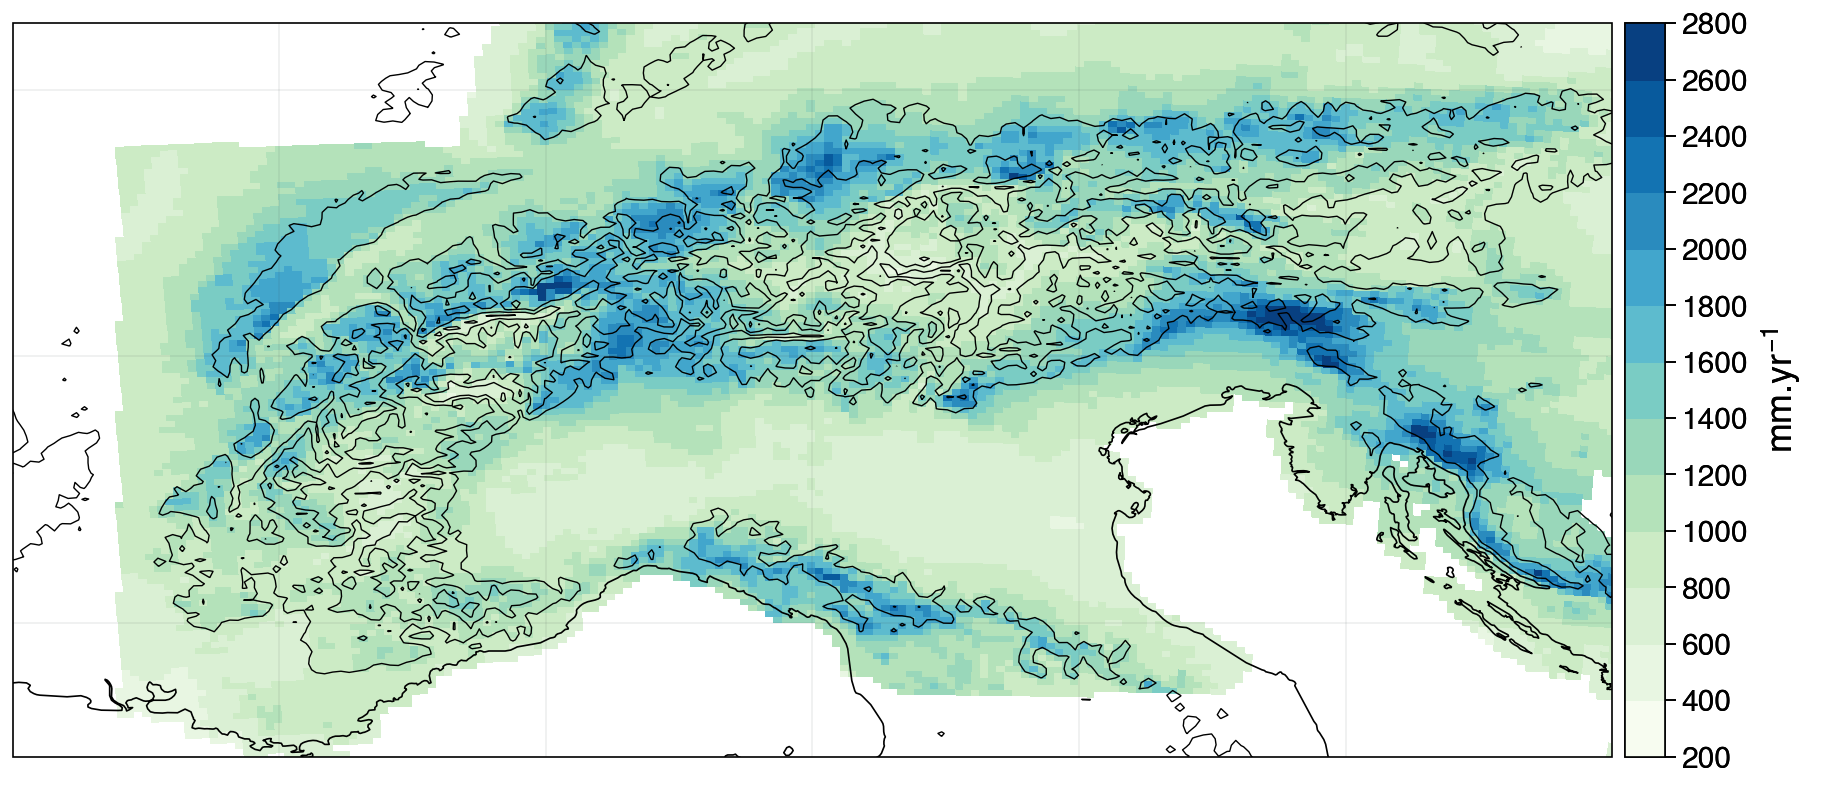

In [8]:
pplt.rc['figure.facecolor'] = 'white'

plot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':False ,'reso':'hi', 'labels':False, 'lonlines':2,
                    'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

# elev_levels = [500, 1000, 1500]
elev_levels = [750, 1500, 2250]

# colmap = 'Blues'
cmap = plt.get_cmap('gnbu').copy()
cmap.set_under('white')
levels_yr = np.arange(200,3000.,200)

f, axs = pplt.subplots(proj='cyl', axwidth=8,ncols=1)

m=axs.pcolormesh(ds_APGD.lon, ds_APGD.lat, ds_APGD.mean(dim="Year"), levels=levels_yr,cmap=cmap)
axs.colorbar(m,label= 'mm.$yr^{-1}$',labelsize='x-large',ticklabelsize='large')
axs.contour(ds_ETOPO_regrid.lon, ds_ETOPO_regrid.lat, ds_ETOPO_regrid.z, levels=elev_levels, colors='black', linewidths=0.5)

f.format(**plot_format)
#f.format(ocean=True,oceancolor='royalblue',reso='hi')#, latlim=[40.,51.],lonlim=[0.,20.])
f.save("/summer/mar/castelli/figs/Manuscript/f2.3.png", dpi=300, bbox_inches='tight')

In [9]:
print(float(ds_ETOPO_regrid.z.min()))
print(float(ds_ETOPO_regrid.z.max()))

-2654.6337890625
3934.74072265625


## Weather regimes

In [16]:
def make_data_array(filein1, latin, lonin):

    arr_cen = np.load(filein1)
    arr_lat = np.load(latin)
    arr_lon = np.load(lonin)

    k, space = arr_cen.shape

    ### Re-shape the array
    centers = np.reshape(arr_cen, (k, len(arr_lat), len(arr_lon)))
    print('---> Shape of the centroids are: ', centers.shape)     #(k, lat, lon)

    ### Cosine of latitude (in radians)
    lat_rad = np.deg2rad(arr_lat)
    coslat = np.sqrt(np.cos(lat_rad))

    ### Divide centroid by cos(lat)
    centers_new = np.zeros((k, len(arr_lat), len(arr_lon)))
    for l in range(0,len(arr_lat)):
        centers_new[:,l,:] = centers[:,l,:]/coslat[l]

    da = xr.DataArray(
        data=centers_new,
        dims=["label", "lat", "lon"],
        coords=dict(
            label=[0,1,2,3],
            lat=arr_lat,
            lon=arr_lon
        ))
    return da

In [18]:
def make_data_array_wind(da_idx, filein_ua, filein_va):

    da_ua = np.load(filein_ua)
    da_va = np.load(filein_va)
    # arr_lat = np.load(latin)
    # arr_lon = np.load(lonin)


    unique_elements, counts_elements = np.unique(da_idx, return_counts=True)

    freq_perc = {}
    freq_perc = counts_elements/len(da_idx) * 100

    n_unique = unique_elements.size
    ua_WT = np.empty((n_unique, da_ua.shape[1], da_va.shape[2]))
    va_WT = np.empty_like(ua_WT)
    for i in range(n_unique):
        mask = (da_idx == i)          # select the right days

        ua_WT[i] = da_ua[mask].mean(axis=0)
        va_WT[i] = da_va[mask].mean(axis=0)

    return ua_WT, va_WT

In [66]:
def plot_4(info, da, ua_wt, va_wt, freq_perc, dict_WT, k=4, row=2, col=2, levels = np.arange(-225,226,25)):
    # k : number of WT
    lon_0  = float(da['lon'].mean())
    lat_0  = float(da['lat'].mean())

    proj = ccrs.LambertConformal(central_longitude=lon_0, central_latitude=lat_0)
    proj_plate = ccrs.PlateCarree()

    fig = plt.figure(figsize=(7,5))

    labels_dataset = [int(v.replace("pr", "")) for v in dict_WT.values()]
    #labels_dataset = list(dict_WT.values())
    keys_WT = list(dict_WT.keys())

    ### Loop to define common characteristics
    for i in range(k):
        ax = fig.add_subplot(row, col, i+1, projection=proj)
        plot = ax.contourf(da['lon'], da['lat'], da[labels_dataset[i],:,:],
                           levels=levels, transform=proj_plate, cmap='RdBu_r', extend='both')
        # cs = ax.contour(lon, lat, alps.astype(int), levels=[0.5], colors="#54278F", transform=proj_plate, zorder=5)

        skip = 7   # thin the field (VERY important visually)

        ax.quiver(
            da['lon'][::skip],
            da['lat'][::skip],
            ua_wt[labels_dataset[i],::skip, ::skip],
            va_wt[labels_dataset[i],::skip, ::skip],
            transform=proj_plate,
            scale=160,          # adjust for arrow size
            width=0.004,
            headwidth=4,
            zorder=6
        )

        ### Colorbar for each plot
        ### See: https://matplotlib.org/3.1.0/gallery/subplots_axes_and_figures/colorbar_placement.html 
        #fig.colorbar(plot, ax=ax, shrink=0.8, orientation='vertical')

        # perc = ',  %2.1f ' %(freq_perc[labels_dataset[i]])
        title_small = keys_WT[i]#+perc+'% freq.'
        ax.set_title(title_small, fontweight='bold')

        ax.gridlines(linewidth=0.75, color='navy', linestyle='dotted')
        ax.coastlines()

    # title = 'Weather Types (WTs) predicted by '+info[0]+' ('+info[1]+', '+info[2]+': '+info[3]+'-'+info[4]+')'
    # fig.suptitle(title, fontsize=15, fontweight='bold')

    ### Add common colorbar: https://stackoverflow.com/questions/13784201/matplotlib-2-subplots-1-colorbar
    fig.subplots_adjust(bottom=0.2)                     # how much space left at the bottom
    cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.02])    #left, bottom, width, height
    cbar = fig.colorbar(plot, cax=cbar_ax, orientation='horizontal', ticks=np.arange(-200, 201, 50))
    cbar.set_label('[m]')
    cbar.locator = plt.FixedLocator(np.arange(-200, 201, 50))
    cbar.update_ticks()
    print(cbar.get_ticks())

    # fig.save("/summer/mar/castelli/figs/Manuscript/f2.4.png", dpi=300, bbox_inches='tight')

In [50]:
# Dictionaries to associate the weather regime to the number found by K-means clustering

dict_WT_ERA5_1960_2009_NDJFM={'NAO+': 'pr0', 'Blocking': 'pr3', 'NAO-': 'pr2', 'Atlantic ridge': 'pr1'}
dict_WT_ERA5_1960_2009_JJA={'NAO+': 'pr2', 'Blocking': 'pr1', 'NAO-': 'pr3', 'Atlantic ridge': 'pr0'}


dict_WT_MPI_hist_1960_2009_NDJFM={'NAO+': 'pr2', 'Blocking': 'pr0', 'NAO-': 'pr3', 'Atlantic ridge': 'pr1'}
dict_WT_MPI_hist_1960_2009_JJA={'NAO+': 'pr3', 'Blocking': 'pr0', 'NAO-': 'pr1', 'Atlantic ridge': 'pr2'}
dict_WT_MPI_ssp245_2050_2099_NDJFM={'NAO+': 'pr0', 'Blocking': 'pr1', 'NAO-': 'pr3', 'Atlantic ridge': 'pr2'}
dict_WT_MPI_ssp245_2050_2099_JJA={'NAO+': 'pr2', 'Blocking': 'pr1', 'NAO-': 'pr0', 'Atlantic ridge': 'pr3'}
dict_WT_MPI_ssp585_2050_2099_NDJFM={'NAO+': 'pr3', 'Blocking': 'pr0', 'NAO-': 'pr2', 'Atlantic ridge': 'pr1'}
dict_WT_MPI_ssp585_2050_2099_JJA={'NAO+': 'pr1', 'Blocking': 'pr0', 'NAO-': 'pr3', 'Atlantic ridge': 'pr2'}

dict_WT_ECEarth3_hist_1960_2009_NDJFM={'NAO+': 'pr3', 'Blocking': 'pr1', 'NAO-': 'pr2', 'Atlantic ridge': 'pr0'}
dict_WT_ECEarth3_hist_1960_2009_JJA={'NAO+': 'pr0', 'Blocking': 'pr2', 'NAO-': 'pr1', 'Atlantic ridge': 'pr3'}
dict_WT_ECEarth3_ssp245_2050_2099_NDJFM={'NAO+': 'pr2', 'Blocking': 'pr3', 'NAO-': 'pr1', 'Atlantic ridge': 'pr0'}
dict_WT_ECEarth3_ssp245_2050_2099_JJA={'NAO+': 'pr1', 'Blocking': 'pr3', 'NAO-': 'pr2', 'Atlantic ridge': 'pr0'}

dict_WT_MPIr2_hist_1960_2009_NDJFM={'NAO+': 'pr2', 'Blocking': 'pr0', 'NAO-': 'pr3', 'Atlantic ridge': 'pr1'}
dict_WT_MPIr3_hist_1960_2009_NDJFM={'NAO+': 'pr0', 'Blocking': 'pr2', 'NAO-': 'pr3', 'Atlantic ridge': 'pr1'}
dict_WT_MPIr4_hist_1960_2009_NDJFM={'NAO+': 'pr3', 'Blocking': 'pr0', 'NAO-': 'pr1', 'Atlantic ridge': 'pr2'}
dict_WT_MPIr5_hist_1960_2009_NDJFM={'NAO+': 'pr3', 'Blocking': 'pr1', 'NAO-': 'pr2', 'Atlantic ridge': 'pr0'}
dict_WT_MPIr6_hist_1960_2009_NDJFM={'NAO+': 'pr2', 'Blocking': 'pr1', 'NAO-': 'pr0', 'Atlantic ridge': 'pr3'}
dict_WT_MPIr7_hist_1960_2009_NDJFM={'NAO+': 'pr1', 'Blocking': 'pr0', 'NAO-': 'pr2', 'Atlantic ridge': 'pr3'}
dict_WT_MPIr8_hist_1960_2009_NDJFM={'NAO+': 'pr0', 'Blocking': 'pr1', 'NAO-': 'pr3', 'Atlantic ridge': 'pr2'}
dict_WT_MPIr9_hist_1960_2009_NDJFM={'NAO+': 'pr1', 'Blocking': 'pr2', 'NAO-': 'pr3', 'Atlantic ridge': 'pr0'}
dict_WT_MPIr10_hist_1960_2009_NDJFM={'NAO+': 'pr2', 'Blocking': 'pr3', 'NAO-': 'pr0', 'Atlantic ridge': 'pr1'}


In [20]:
case = 'hist'

season = 'winter'
datestart = '1960-01-01'
dateend   = '2009-12-31'
yearstart = '1960'
yearend = '2009'

refone = 'T'
m = 'ERA5'

list_info = [m, case, season, yearstart, yearend, refone]

In [19]:

rootstore = '/bettik/castelli/data/WTD/'+m+'/'+case+'/1.0degree'
rootstore2 = '/bettik/castelli/data/WTD/'+m+'/'+case+'/winds/1.0degree'

if refone=='T':
    filein1  = os.path.join(rootstore, m+'_AtlEurSector_centers_1.0_'+season+'_'+yearstart+'-'+yearend+'.npy')
    filein2  = os.path.join(rootstore, m+'_AtlEurSector_labels_1.0_'+season+'_'+yearstart+'-'+yearend+'.npy')
    filein_ua = os.path.join(rootstore2, m+'_AtlEurSector_1.0_anomaliesWGT_ua500_'+season+'_'+datestart+'_'+dateend+'.npy')
    filein_va = os.path.join(rootstore2, m+'_AtlEurSector_1.0_anomaliesWGT_va500_'+season+'_'+datestart+'_'+dateend+'.npy')
if refone == 'F' and case != 'hist':
    filein1  = os.path.join(rootstore, m+'_AtlEurSector_centers_1.0_'+season+'_'+yearstart+'-'+yearend+'_bis.npy')
    filein2  = os.path.join(rootstore, m+'_AtlEurSector_labels_1.0_'+season+'_'+yearstart+'-'+yearend+'_bis.npy')
    filein_ua = os.path.join(rootstore2, m+'_AtlEurSector_1.0_anomaliesWGT_ua500_'+season+'_'+datestart+'_'+dateend+'_bis.npy')
    filein_va = os.path.join(rootstore2, m+'_AtlEurSector_1.0_anomaliesWGT_va500_'+season+'_'+datestart+'_'+dateend+'_bis.npy')

latin    = os.path.join(rootstore, m+'_lat_1.0_AtlEurSector.npy')
lonin    = os.path.join(rootstore, m+'_lon_1.0_AtlEurSector.npy')

da_ERA5 = make_data_array(filein1,latin,lonin)

idx_ERA5 = np.load(filein2)

unique_elements_ERA5, counts_elements_ERA5 = np.unique(idx_ERA5, return_counts=True)

freq_perc_ERA5 = counts_elements_ERA5/len(idx_ERA5) * 100

ua_WT_ERA5, va_WT_ERA5 = make_data_array_wind(idx_ERA5, filein_ua, filein_va)

---> Shape of the centroids are:  (4, 61, 131)


[-200 -150 -100  -50    0   50  100  150  200]


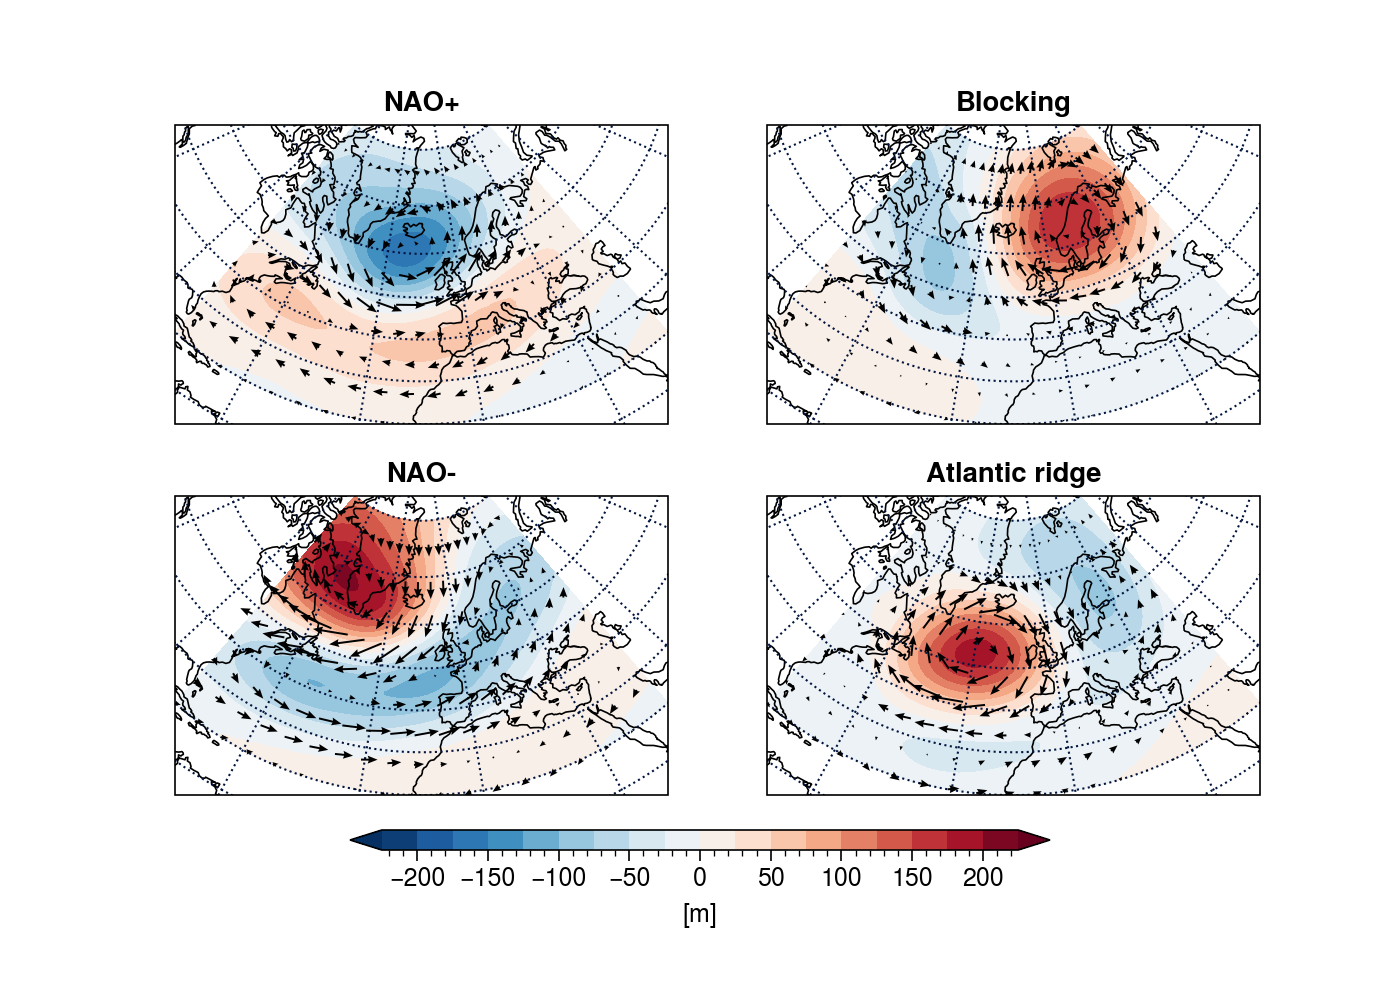

In [67]:
plot_4(list_info, da_ERA5, ua_WT_ERA5, va_WT_ERA5, freq_perc_ERA5, dict_WT_ERA5_1960_2009_NDJFM)